# Calculate all subjects' dissim ~ genmag, spread

20251203 ~ 20260102

To create the library, implement and test the function here.

Calculate genmag and spread then store in work/data/processed as hdf style.

In [1]:
import os
import sys
import numpy as np
import pandas as pd

project_root = os.path.abspath("/home/jovyan/work")
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from funcs import core, viz

Project root: /home/jovyan/work


In [2]:
d_path = "/home/jovyan/work/data/raw/Amy_dissimilarity.csv"
unique_words = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "brown", "grey", "black", "happiness", "joy", "confidence", "calm", "boredom", "confusion", "anxiety", "fear", "sadness", "defeated", "anger", "envy", "disgust"]
n_sub = 120
raw = pd.read_csv(d_path, header=None)
raw.drop(columns=0, inplace=True)
raw

,1,2,3,4,5,6,7,8,9,10,...,244,245,246,247,248,249,250,251,252,253
0,brown,orange,red,black,green,red,envy,fear,pink,blue,...,blue,blue,fear,purple,disgust,calm,orange,green,brown,anxiety
1,anger,anxiety,yellow,blue,calm,pink,joy,anger,green,anger,...,envy,anxiety,happiness,confidence,defeated,happiness,pink,disgust,joy,boredom
2,6,2,2,1,0,0,7,0,2,6,...,1,2,7,2,5,2,3,0,4,5
3,6,6,3,6,6,6,7,6,3,7,...,6,7,7,6,1,6,4,6,6,1
4,7,7,0,2,3,3,7,5,3,7,...,6,6,7,6,1,1,3,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,6,6,0,0,5,0,2,0,1,5,...,5,5,2,5,3,1,3,6,7,2
118,7,7,6,5,4,2,7,2,5,7,...,3,6,7,3,2,0,2,1,7,7
119,7,7,4,3,3,2,7,3,5,7,...,5,7,7,2,6,0,1,7,7,4
120,7,7,1,2,3,0,6,2,3,5,...,4,6,6,5,3,3,4,2,6,3


In [3]:
# define t

t1 = np.logspace(-4, -1, 20, endpoint=False)   # 10^-4 ～ 10^-1
t2 = np.logspace(-1,  2, 500, endpoint=False)  # 10^-1 ～ 10^2
t3 = np.logspace(2,  4, 20, endpoint=False)    # 10^2 ～ 10^4
t4 = np.logspace(4, 8, 20, endpoint=True)

t_all = np.concatenate([t1, t2, t3, t4])

In [11]:
genmag_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

positive_definite_t_all = pd.DataFrame(
    data=pd.NA,
    index=np.arange(n_sub),
    columns=t_all,
    dtype="boolean"
)

In [12]:
positive_definite_t_all

,1.000000e-04,1.412538e-04,1.995262e-04,2.818383e-04,3.981072e-04,5.623413e-04,7.943282e-04,1.122018e-03,1.584893e-03,2.238721e-03,...,1.274275e+06,2.069138e+06,3.359818e+06,5.455595e+06,8.858668e+06,1.438450e+07,2.335721e+07,3.792690e+07,6.158482e+07,1.000000e+08
0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
116,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
117,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
118,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [13]:
h5_path = project_root + "/data/processed/amy_processeddata_all.h5"

with pd.HDFStore(h5_path, mode="w") as store:

    for sub in range(n_sub):
        print(f'subject: {sub}')
        dissim_mtx = core.create_dissim_amy(raw, sub_no=sub, unique_words=unique_words)
        dist = core.cal_dissim2dist(dissim_mtx)
        store.put(f"/dissim/sub_{sub:03d}", dissim_mtx, format="fixed")

        for i_t, t in enumerate(t_all):
            sim = core.cal_dist2sim(dist, t)
            genmag = core.cal_sim2genmag(sim)
            genmag_all.iloc[sub, i_t] = genmag

            spr = core.cal_dist2spread(dist, t)
            spr_all.iloc[sub, i_t] = spr

            A = sim.to_numpy()
            is_pd = core.check_positivedefinite(A)
            positive_definite_t_all.iloc[sub, i_t] = bool(is_pd)

subject: 0
subject: 1
subject: 2
subject: 3
subject: 4
subject: 5
subject: 6
subject: 7
subject: 8
subject: 9
subject: 10
subject: 11
subject: 12
subject: 13
subject: 14
subject: 15
subject: 16
subject: 17
subject: 18
subject: 19
subject: 20
subject: 21
subject: 22
subject: 23
subject: 24
subject: 25
subject: 26
subject: 27
subject: 28
subject: 29
subject: 30
subject: 31
subject: 32
subject: 33
subject: 34
subject: 35
subject: 36
subject: 37
subject: 38
subject: 39
subject: 40
subject: 41
subject: 42
subject: 43
subject: 44
subject: 45
subject: 46
subject: 47
subject: 48
subject: 49
subject: 50
subject: 51
subject: 52
subject: 53
subject: 54
subject: 55
subject: 56
subject: 57
subject: 58
subject: 59
subject: 60
subject: 61
subject: 62
subject: 63
subject: 64
subject: 65
subject: 66
subject: 67
subject: 68
subject: 69
subject: 70
subject: 71
subject: 72
subject: 73
subject: 74
subject: 75
subject: 76
subject: 77
subject: 78
subject: 79
subject: 80
subject: 81
subject: 82
subject: 83
su

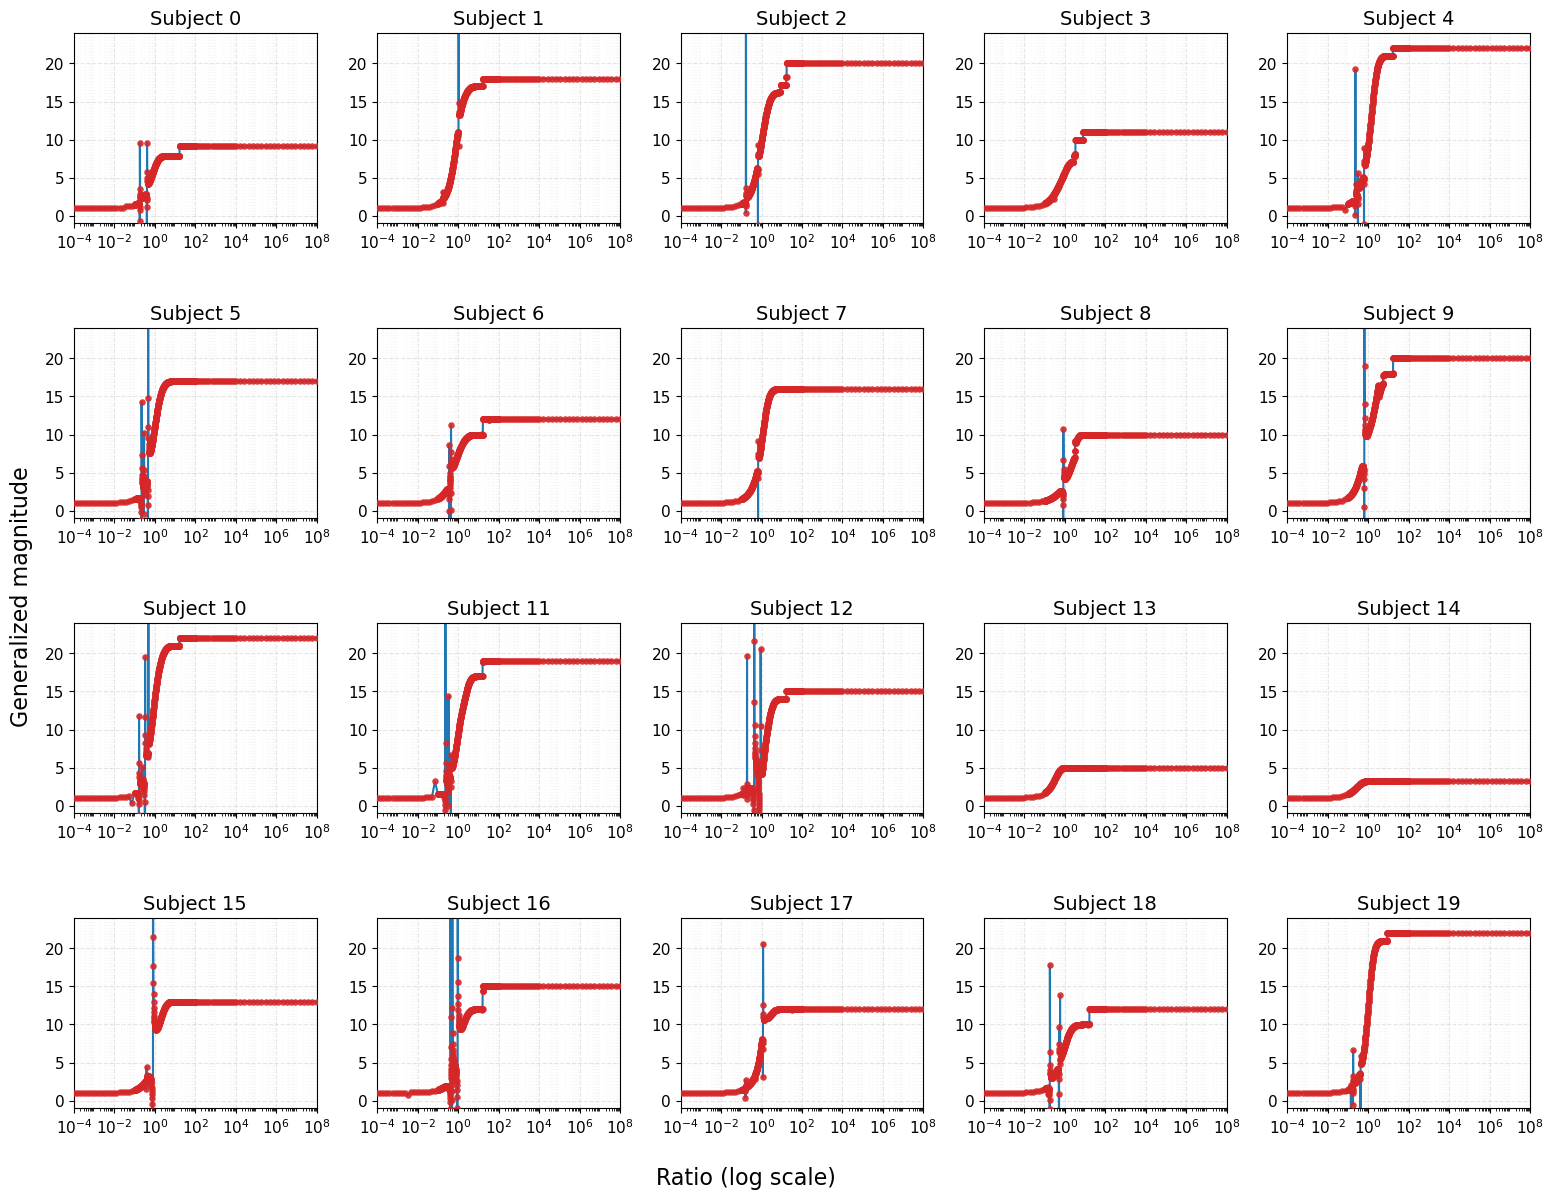

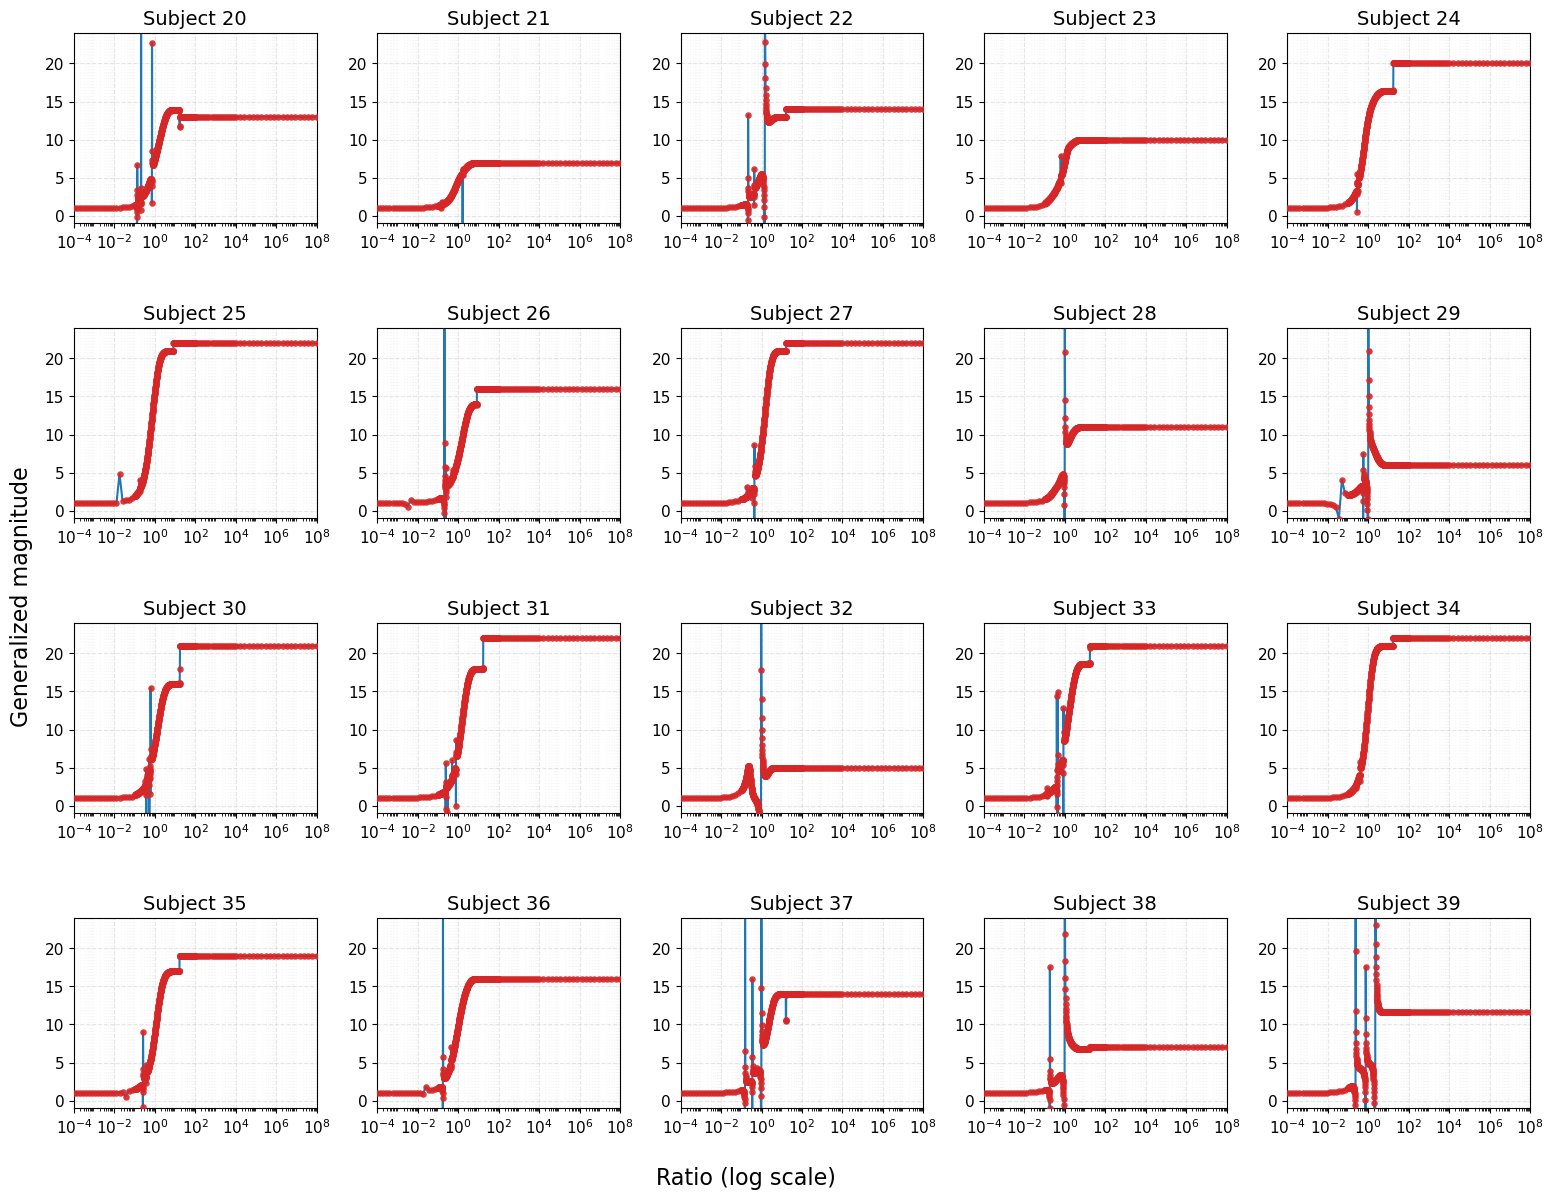

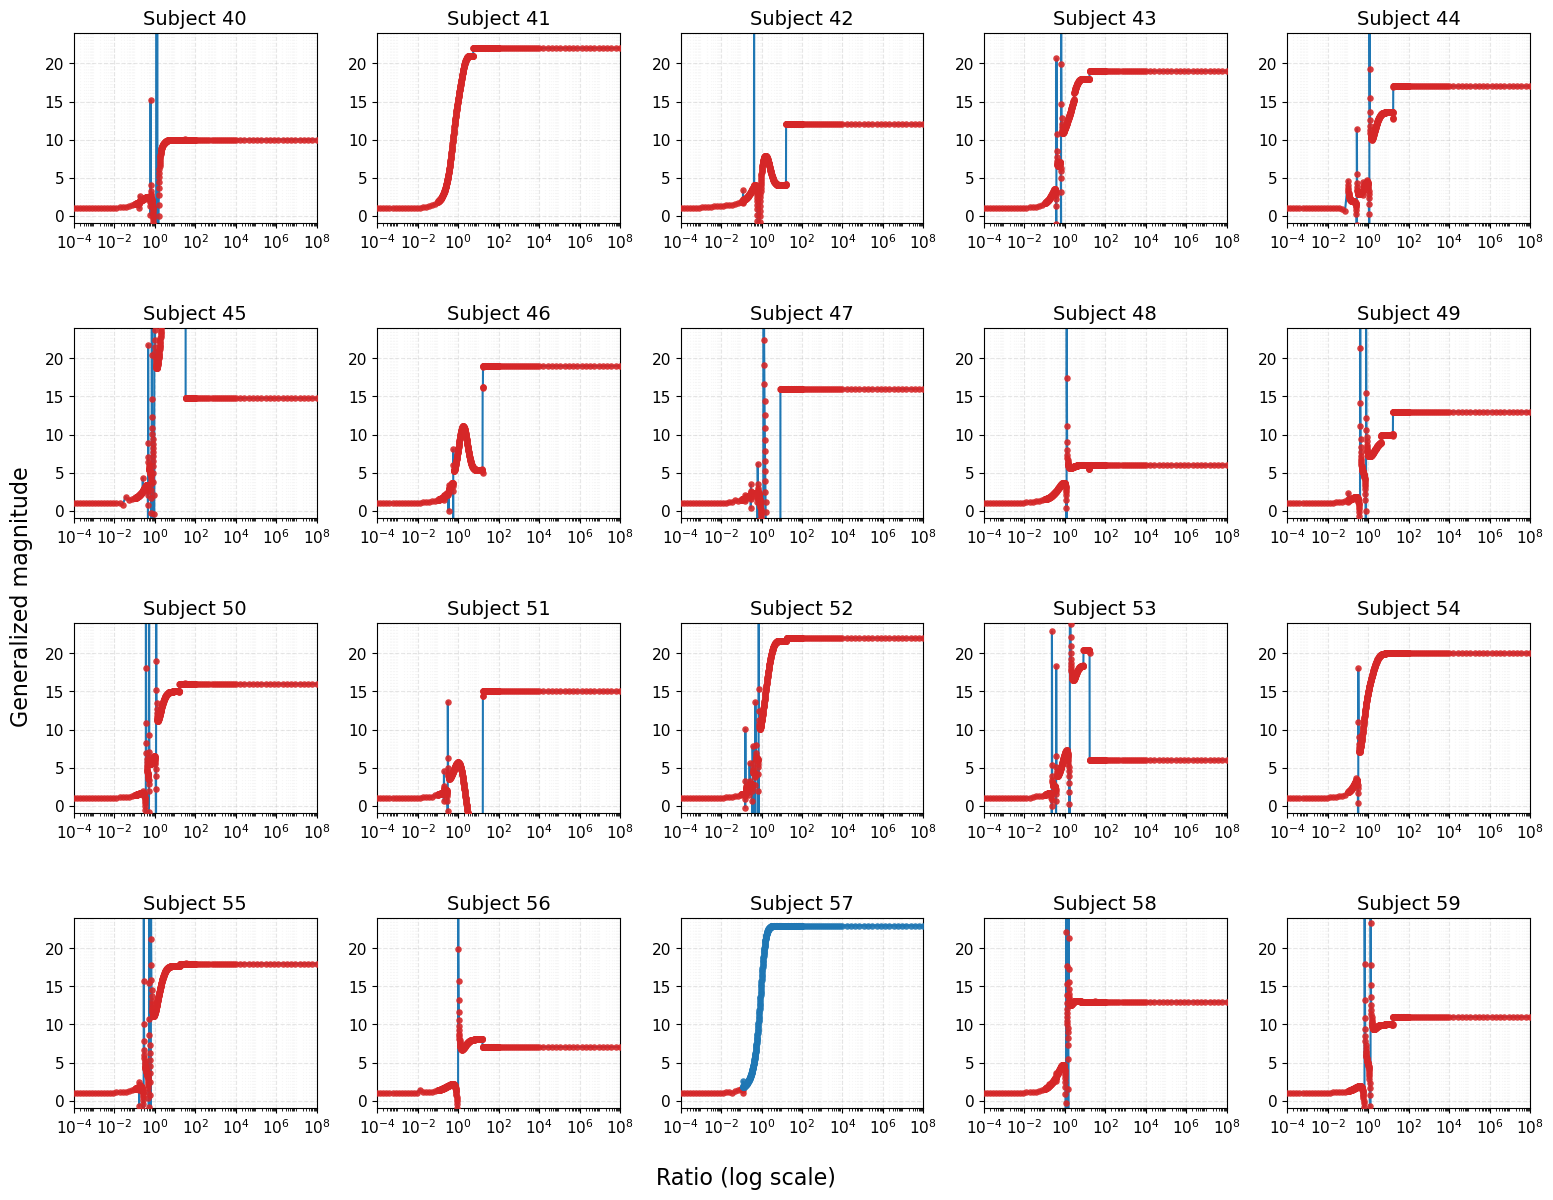

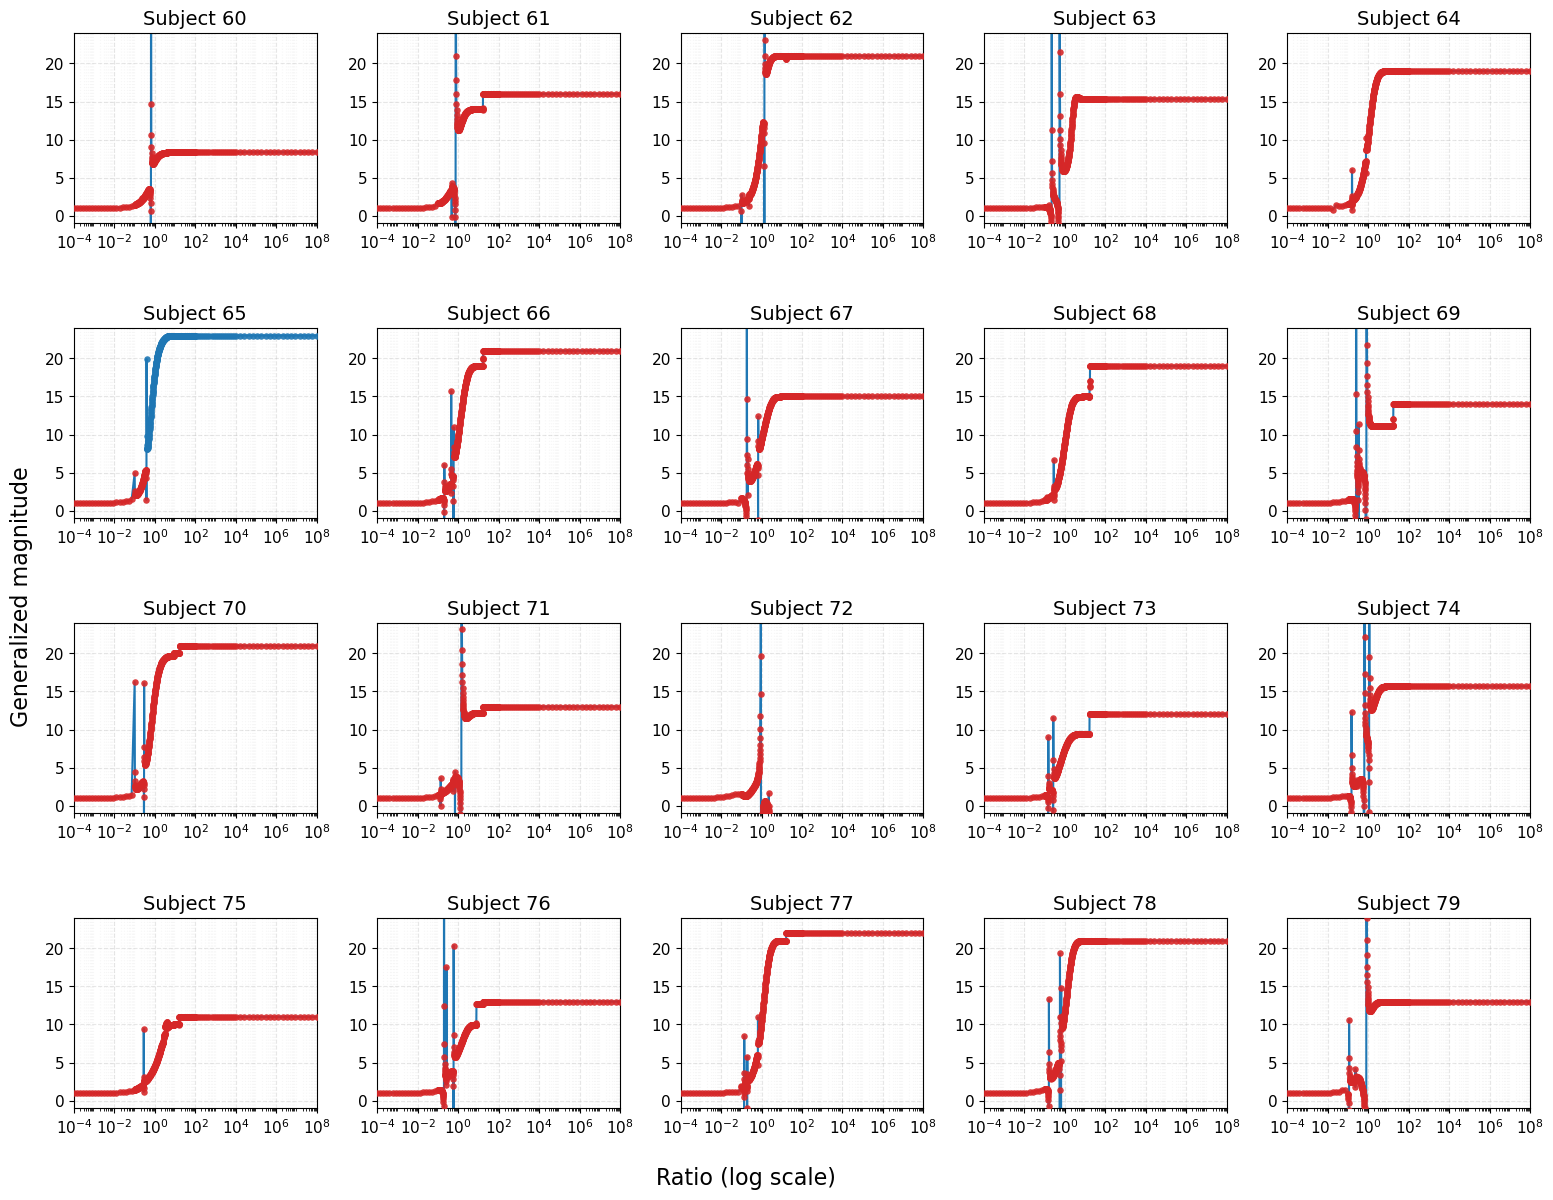

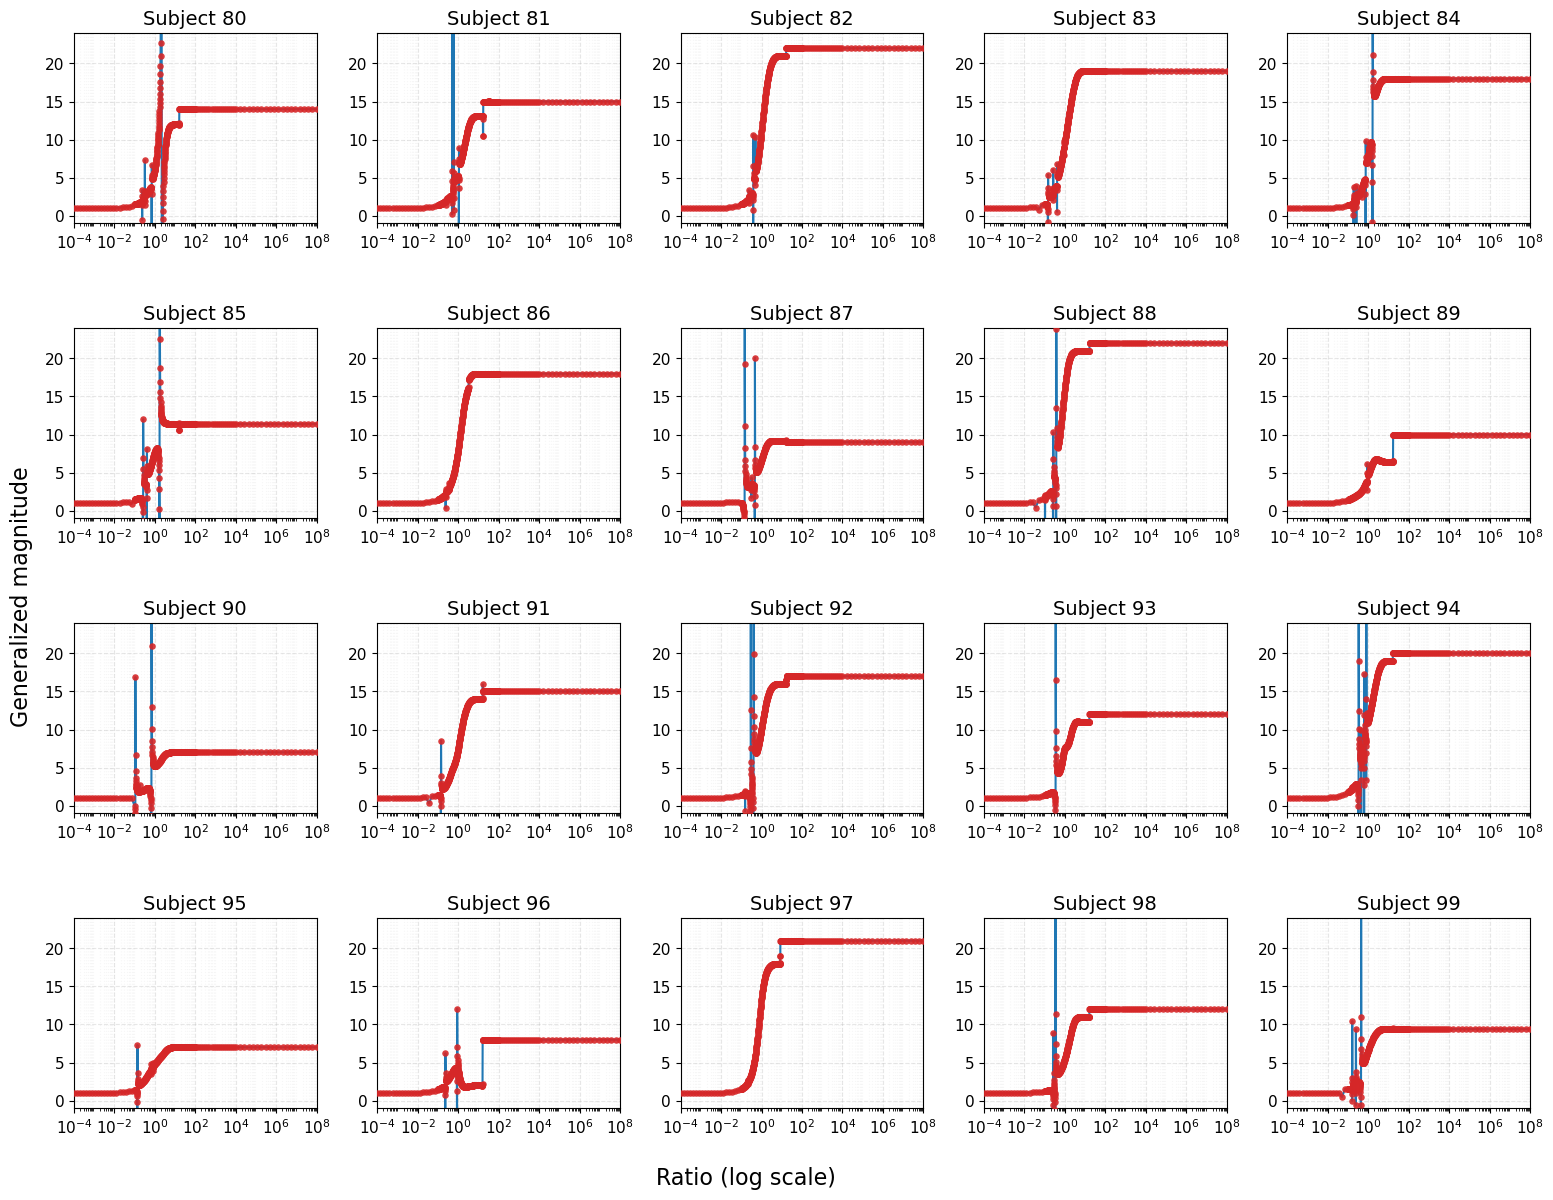

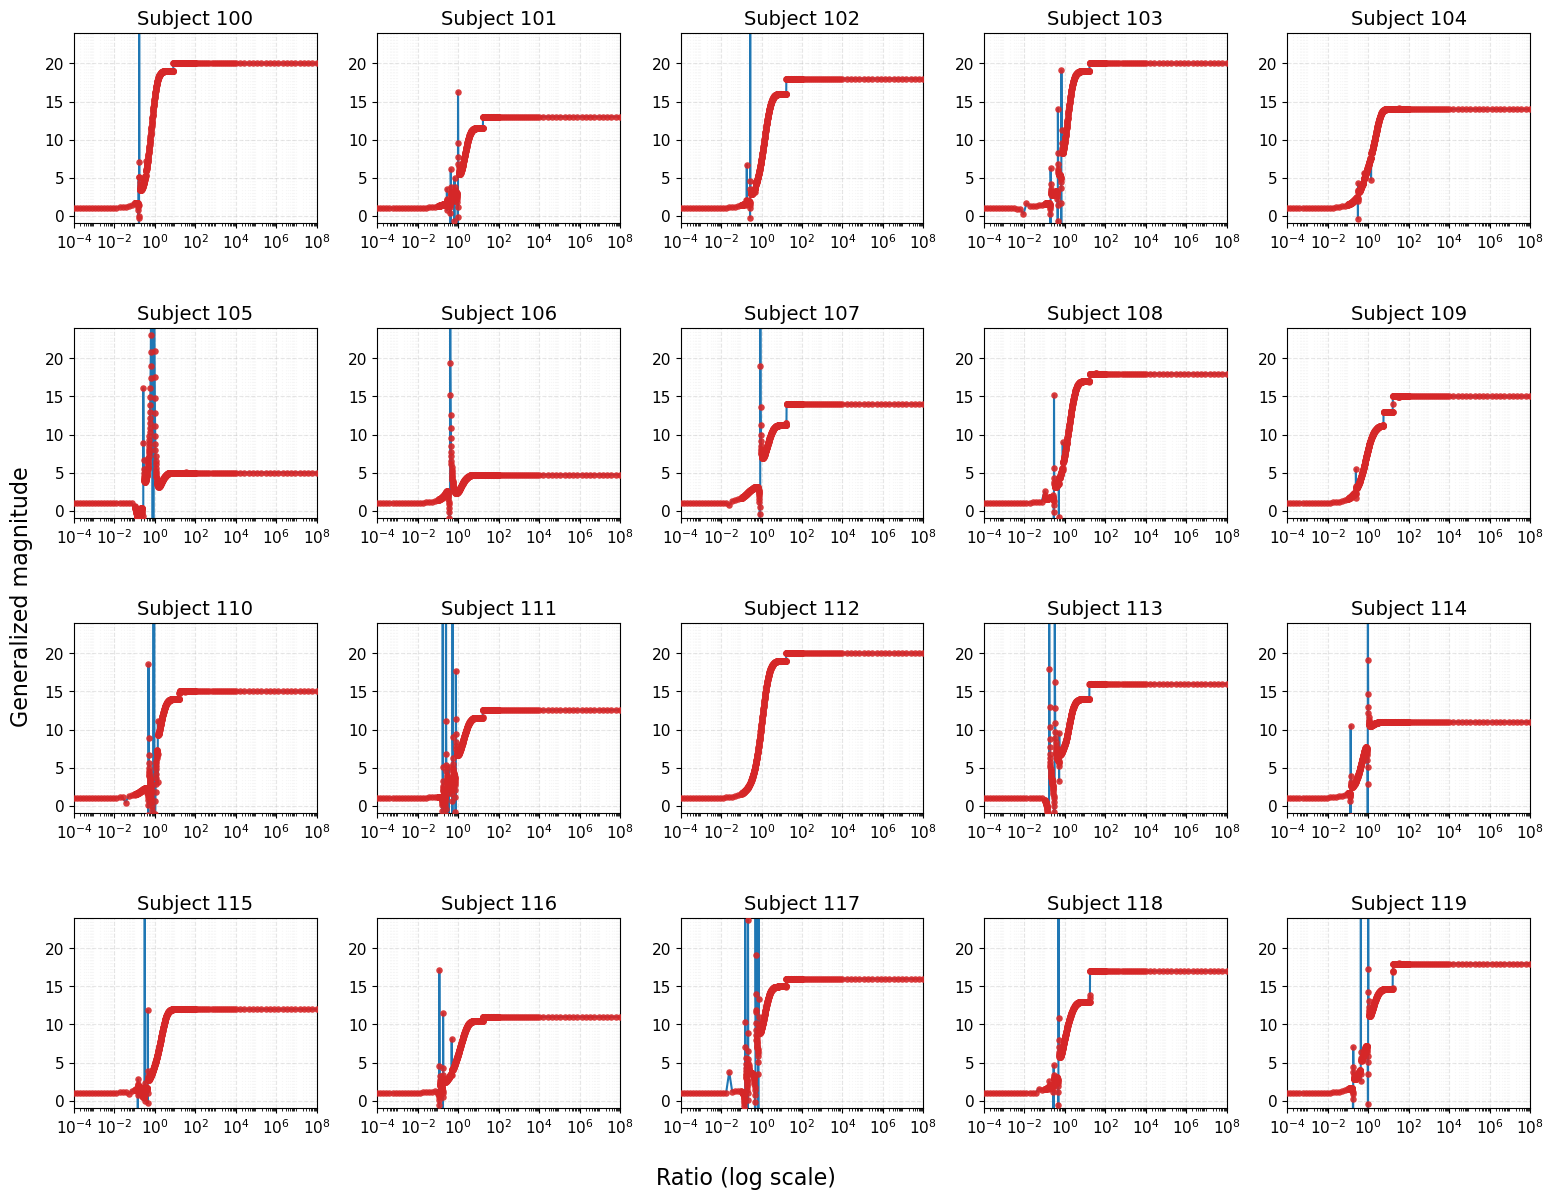

['/home/jovyan/work/fig/temp/Generalized magnitude_page01.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page02.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page03.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page04.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page05.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page06.png']

In [20]:
output = os.path.join(project_root, "fig/temp")

viz.plt_metric_individual(
    genmag_all,
    metric_name="Generalized magnitude",
    output_dir=output,
    nrows=4, ncols=5,
    ylim=[-1, 24], xlim=None,
    xticks_all=True, yticks_all=True, 
    positive_definite_df=positive_definite_t_all,
    posdef_mode= "two_color",
)

In [22]:
if genmag_all.columns.is_unique is False or spr_all.columns.is_unique is False:
    raise ValueError("Keys of columns are not unique. Recommend checking t setting.")


positive_definite_df = positive_definite_t_all.astype("bool") 
with pd.HDFStore(h5_path, mode="a") as store:
    store.put("/metrics/genmag", genmag_all, format="fixed")
    store.put("/metrics/spread", spr_all, format="fixed")
    store.put("/metrics/positivedefinite", positive_definite_df, format="fixed")

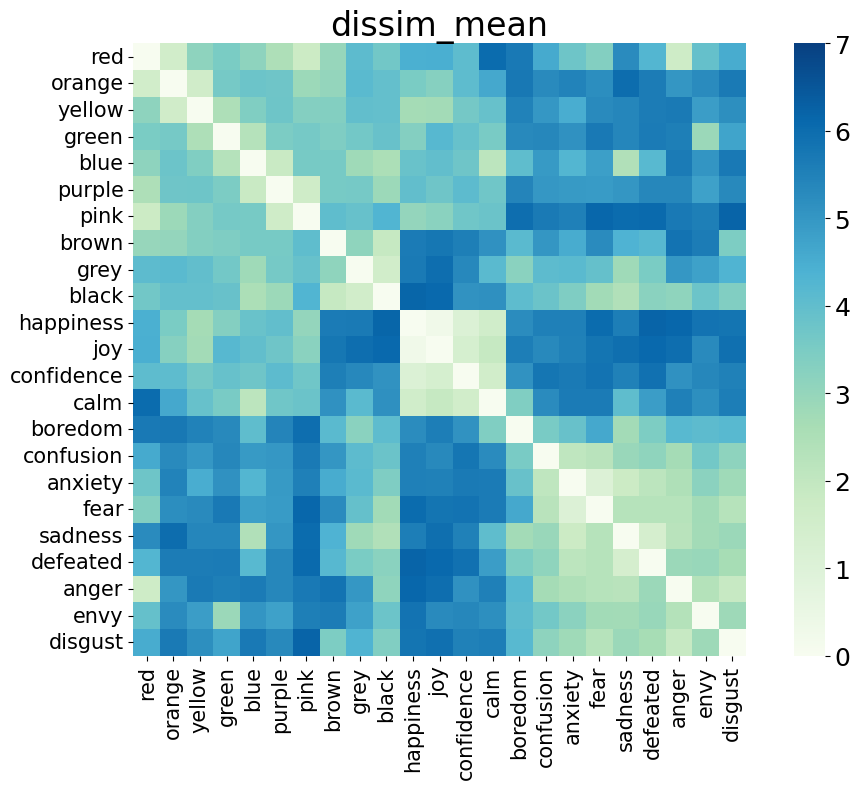

In [19]:
# all subjects mean
n_sub = 1
i_sub = 0

genmag_mean = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_mean = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

positive_definite_t_mean = pd.DataFrame(
    data=pd.NA,
    index=np.arange(n_sub),
    columns=t_all,
    dtype="boolean"
)

dissim_mtx = core.create_dissim_amy(raw, sub_no=-1, unique_words=unique_words)
dist = core.cal_dissim2dist(dissim_mtx)

viz.plt_dissim_heatmap(
    dissim_mtx,
    mode_dissim=True,
    save=True,
    figpath=project_root + "/fig/dissim/dissim_mean.jpg")

In [24]:
for i_t, t in enumerate(t_all):
    sim = core.cal_dist2sim(dist, t)
    genmag = core.cal_sim2genmag(sim)
    genmag_mean.iloc[0, i_t] = genmag

    spr = core.cal_dist2spread(dist, t)
    spr_mean.iloc[0, i_t] = spr

    A = sim.to_numpy()
    is_pd = core.check_positivedefinite(A)
        positive_definite_t_mean.iloc[i_sub, i_t] = bool(is_pd)

iter 0, 0.0001
iter 1, 0.0001412537544622754
iter 2, 0.00019952623149688788
iter 3, 0.0002818382931264455
iter 4, 0.00039810717055349735
iter 5, 0.0005623413251903491
iter 6, 0.0007943282347242813
iter 7, 0.001122018454301963
iter 8, 0.001584893192461114
iter 9, 0.0022387211385683377
iter 10, 0.0031622776601683794
iter 11, 0.0044668359215096305
iter 12, 0.00630957344480193
iter 13, 0.008912509381337459
iter 14, 0.012589254117941675
iter 15, 0.01778279410038923
iter 16, 0.025118864315095794
iter 17, 0.03548133892335753
iter 18, 0.0501187233627272
iter 19, 0.0707945784384138
iter 20, 0.1
iter 21, 0.10139113857366794
iter 22, 0.10280162981264736
iter 23, 0.10423174293933042
iter 24, 0.10568175092136585
iter 25, 0.10715193052376065
iter 26, 0.10864256236170655
iter 27, 0.11015393095414151
iter 28, 0.11168632477805612
iter 29, 0.11324003632355571
iter 30, 0.1148153621496883
iter 31, 0.11641260294104915
iter 32, 0.11803206356517298
iter 33, 0.11967405313072434
iter 34, 0.12133888504649772
it

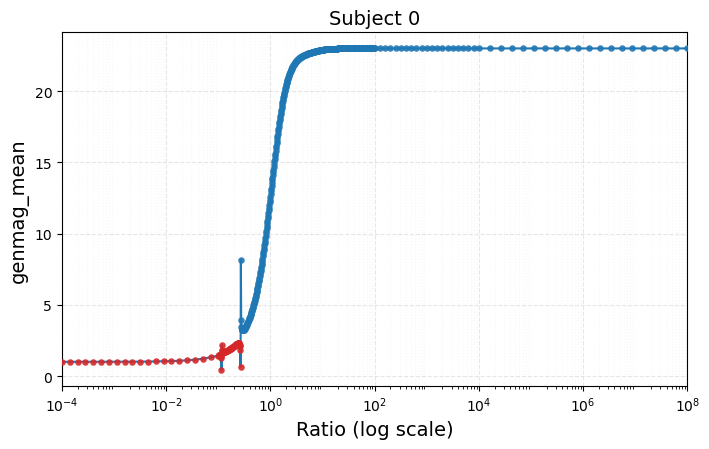

out/genmag_mean_sub0.png


In [42]:
out = plt_metric_single(
    metric_df=genmag_mean,
    subject=0,
    metric_name="genmag_mean",
    output_dir="out",
    positive_definite_df=positive_definite_t_mean,
    posdef_mode="two_color",   # or "true_only"
)
print(out)